# Text Classification using TensorFlow

## Dataset
SMS Spam Collection Dataset (Kaggle)

## Objective
To classify SMS messages as Spam or Ham using TensorFlow and Keras.

## Tools Used
- Python
- TensorFlow
- Keras
- Pandas
- NumPy
- Matplotlib

In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [21]:
# Load the dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
# Check dataset information
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [23]:
# Convert ham -> 0 and spam -> 1

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [24]:
# Features and labels

X = df['message']
y = df['label']

# Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [25]:
max_features = 10000
sequence_length = 100

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

vectorize_layer.adapt(X_train)

In [26]:
model = tf.keras.Sequential([
    vectorize_layer,

    tf.keras.layers.Embedding(
        input_dim=max_features,
        output_dim=16
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Convert text and labels into proper formats

X_train = X_train.astype(str).values
X_test = X_test.astype(str).values

y_train = y_train.values
y_test = y_test.values

print(type(X_train))
print(X_train.dtype)

<class 'numpy.ndarray'>
object


In [29]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8603 - loss: 0.3939 - val_accuracy: 0.8621 - val_loss: 0.3765
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8670 - loss: 0.3639 - val_accuracy: 0.8621 - val_loss: 0.3714
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3579 - val_accuracy: 0.8621 - val_loss: 0.3643
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3484 - val_accuracy: 0.8621 - val_loss: 0.3534
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3331 - val_accuracy: 0.8621 - val_loss: 0.3307
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8670 - loss: 0.3021 - val_accuracy: 0.8621 - val_loss: 0.2846
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8892 - loss: 0.2367 - val_accuracy: 0.9159 - val_loss: 0.2024
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9428 - loss: 0.1646 - val_accuracy: 

In [30]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9758 - loss: 0.1043
Test Loss: 0.1043051928281784
Test Accuracy: 0.9757847785949707


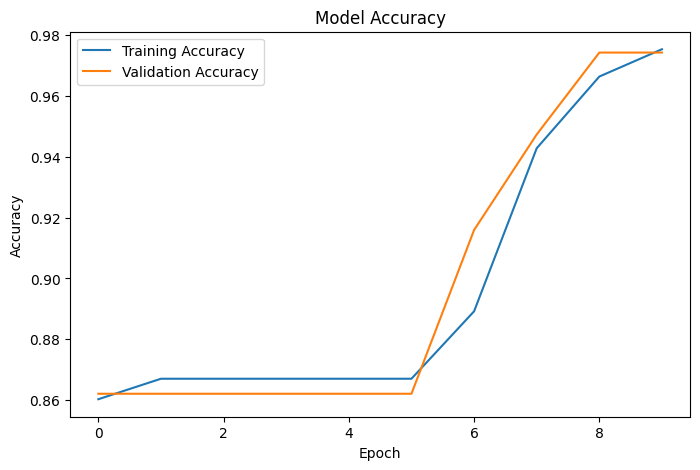

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

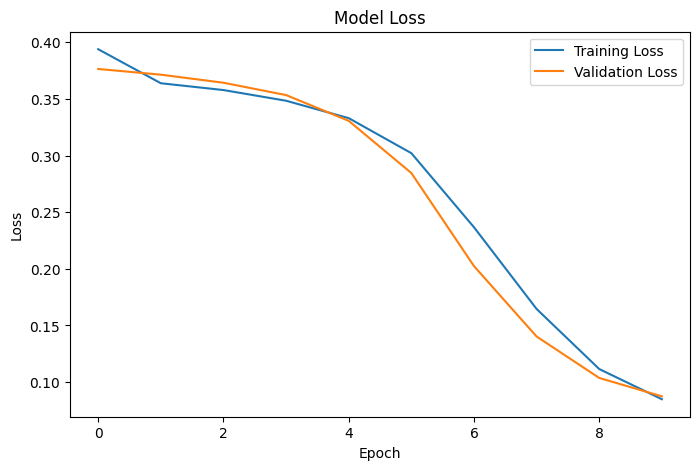

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Conclusion

A TensorFlow-based text classification model was developed using the SMS Spam Collection Dataset.

The dataset was preprocessed, labels were encoded, and a neural network was trained using TensorFlow and Keras.

The model achieved high classification accuracy and successfully distinguished between spam and legitimate SMS messages.

This project demonstrates the application of Natural Language Processing (NLP) and Deep Learning techniques for text classification.
